<a href="https://colab.research.google.com/github/AlexitoFernandez/practicas-google-colab/blob/unidad-4/Practica_3_PCA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#"Machine Learning y Deep Learning"
##Unidad IV
### **Practica 3 - Análisis de Componentes Principales (PCA)**
Alumno: Jorge Alejandro Fernández De Los Santos.

Facilitador: José Gabriel Rodríguez Rivas.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import gdown

# Cargar datos
file_id = '1HBU_efbbPg378pZvLZ1AtvRFAKrEFsob'
output = 'lending_club_2007_2011_6_states.csv'
gdown.download(id=file_id, output=output, quiet=False)
prestamos= pd.read_csv(output)
print(prestamos.head())

Downloading...
From: https://drive.google.com/uc?id=1HBU_efbbPg378pZvLZ1AtvRFAKrEFsob
To: /content/lending_club_2007_2011_6_states.csv
100%|██████████| 7.01M/7.01M [00:00<00:00, 169MB/s]


   loan_amnt  funded_amnt  funded_amnt_inv       term  int_rate  installment  \
0       2400         2400           2400.0  36 months     15.96        84.33   
1      10000        10000          10000.0  36 months     13.49       339.31   
2       3000         3000           3000.0  36 months     18.64       109.43   
3       5600         5600           5600.0  60 months     21.28       152.39   
4       5375         5375           5350.0  60 months     12.69       121.45   

  grade sub_grade            emp_title emp_length  ... application_type  \
0     C        C5                  NaN  10+ years  ...       Individual   
1     C        C1  AIR RESOURCES BOARD  10+ years  ...       Individual   
2     E        E1      MKC Accounting     9 years  ...       Individual   
3     F        F2                  NaN    4 years  ...       Individual   
4     B        B5            Starbucks   < 1 year  ...       Individual   

   acc_now_delinq chargeoff_within_12_mths delinq_amnt pub_rec_bankr

In [3]:
model_columns = ['funded_amnt', "int_rate", "grade", 'purpose',
'addr_state',
'home_ownership', 'annual_inc', 'dti', 'revol_util',
'pub_rec_bankruptcies']
X = prestamos[model_columns]
X.head()

,funded_amnt,int_rate,grade,purpose,addr_state,home_ownership,annual_inc,dti,revol_util,pub_rec_bankruptcies
0,2400,15.96,C,small_business,IL,RENT,12252.0,8.72,98.5,0.0
1,10000,13.49,C,other,CA,RENT,49200.0,20.00,21.0,0.0
2,3000,18.64,E,car,CA,RENT,48000.0,5.35,87.5,0.0
3,5600,21.28,F,small_business,CA,OWN,40000.0,5.55,32.6,0.0
4,5375,12.69,B,other,TX,RENT,15000.0,18.08,36.5,0.0


In [7]:
y = prestamos['loan_status']
y.head()

,loan_status
0,Fully Paid
1,Fully Paid
2,Fully Paid
3,Charged Off
4,Charged Off


In [9]:
#Escalar los datos

# Convertir columnas categóricas a numéricas usando one-hot encoding
X_encoded = pd.get_dummies(X, columns=['grade', 'purpose', 'addr_state', 'home_ownership'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled

array([[-1.20758742,  1.04653339, -0.84266705, ..., -0.04706445,
        -0.29016482,  0.90301136],
       [-0.14851581,  0.37863978, -0.31335565, ..., -0.04706445,
        -0.29016482,  0.90301136],
       [-1.1239765 ,  1.77121147, -0.33054667, ..., -0.04706445,
        -0.29016482,  0.90301136],
       ...,
       [ 1.94175711, -0.4055268 , -0.33054667, ..., -0.04706445,
        -0.29016482,  0.90301136],
       [-1.1239765 , -0.4893515 ,  1.84698211, ..., -0.04706445,
        -0.29016482, -1.10740579],
       [-0.84527345, -0.57588023, -0.33054667, ..., -0.04706445,
        -0.29016482, -1.10740579]])

In [13]:
#Aplicar PCA
from sklearn.impute import SimpleImputer

# Imputar NaNs en X_scaled antes de aplicar PCA
imputer = SimpleImputer(strategy='median')
X_scaled_imputed = imputer.fit_transform(X_scaled)

# Inicializar PCA y especificar el número de componentes principales deseados
pca = PCA(n_components=2)  # Elegimos 2 componentes para visualización
X_pca = pca.fit_transform(X_scaled_imputed)
# Mostrar la proporción de varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acumulada:", np.cumsum(explained_variance))

Proporción de varianza explicada por cada componente: [0.07021705 0.05018117]
Varianza explicada acumulada: [0.07021705 0.12039822]


**Explicación**
* El primer componente principal (PC1) explica aproximadamente el 7.02% de la variabilidad total de los datos. Esto significa que casi una cuarta parte de la información en las variables originales puede representarse mediante este componente.

* El segundo componente principal (PC2) explica alrededor del 5.01% de la variabilidad total. Este segundo componente captura información adicional no explicada por el primero, pero en menor medida.

* Los 2 componentes explican apenas el 12.03% de la variabilidad de la informacion, por lo tanto no es suficiente y es necesario
especificar más componentes.

In [15]:
#Realizar PCA y Especificar 6 componentes
pca = PCA(n_components=6)  # Elegimos 6 componentes
X_pca = pca.fit_transform(X_scaled_imputed)
# Mostrar la proporción de varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acumulada:", np.cumsum(explained_variance))

Proporción de varianza explicada por cada componente: [0.07021705 0.05018117 0.04425166 0.04007489 0.0382851  0.03639015]
Varianza explicada acumulada: [0.07021705 0.12039822 0.16464988 0.20472478 0.24300987 0.27940003]


**Interpretación**
* La Varianza acumulada de los 6 componentes es del 27.94%.
* El resto de la información (72.06%) está distribuida entre los componentes restantes.A pesar de reducir la dimensionalidad de los datos, trabajar únicamente con los primeros 6 componentes implica conservar solo cerca del 28% de la información original, lo cual es un porcentaje bajo para la mayoría de los análisis.
* Decidir cuántos componentes mantener depende del umbral de varianza acumulada que consideres suficiente; por ejemplo, si el objetivo es conservar al menos el 80% o 90%, necesitaremos incluir significativamente más componentes en el modelo, ya que los primeros 6 no logran capturar la mayor parte de la variabilidad.
* Cada componente principal es una combinación lineal de las variables originales, y los coeficientes asociados a estas variables.
* Cada componente principal (PC1) es una suma ponderada de las variables originales ($PC1 = a_1X_1 + a_2X_2 + a_3X_3 + \dots + a_nX_n$).
Donde $a_1, a_2, a_3 \dots a_n$ son los coeficientes o pesos que determinan cuánto contribuye cada variable $X_1, X_2, X_3 \dots X_n$.

In [17]:
# Coeficientes de las variables
componentes = pd.DataFrame(
pca.components_,
columns=X_encoded.columns,
index=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print("Contribución de variables a cada componente:")
print(componentes)

Contribución de variables a cada componente:
     funded_amnt  int_rate  annual_inc       dti  revol_util  \
PC1     0.288518  0.537329    0.057355  0.201586    0.418813   
PC2    -0.337743 -0.092677   -0.355707  0.169333    0.154811   
PC3     0.187398 -0.229100    0.006928  0.216657   -0.044221   
PC4     0.211254  0.019377    0.252911 -0.411731   -0.217590   
PC5     0.165597  0.004888    0.110312  0.138659    0.145189   
PC6     0.147609 -0.126413    0.249009 -0.000151   -0.014848   

     pub_rec_bankruptcies   grade_B   grade_C   grade_D   grade_E  ...  \
PC1              0.041828 -0.221432  0.100195  0.245507  0.264321  ...   
PC2              0.011014  0.064179  0.081725  0.020015 -0.120643  ...   
PC3             -0.045128  0.384513 -0.250298 -0.156550 -0.089410  ...   
PC4             -0.103514  0.084889 -0.243752  0.009032  0.103294  ...   
PC5              0.009389  0.408751 -0.391119 -0.044001  0.054542  ...   
PC6             -0.008220 -0.147074  0.589088 -0.421921 -0.138

**PC1: Perfil de Riesgo y Tasa de Interés Alta
Variables Clave:** int_rate (+0.537), revol_util (+0.418), funded_amnt (+0.288) junto con grados de riesgo más altos como grade_E (+0.264) y grade_D (+0.245).

  * Interpretación: Este componente captura el nivel de riesgo y costo del crédito. Valores altos en PC1 representan perfiles de préstamos grandes, con tasas de interés elevadas, alto uso de la línea de crédito revolvente y calificaciones de riesgo desfavorables (D y E).

**PC2: Capacidad Financiera vs. Vivienda en Renta
Variables Clave:** home_ownership_RENT (+0.544), annual_inc (-0.355), funded_amnt (-0.337) y home_ownership_OWN (-0.240).

  * Interpretación PC2: contrasta la estabilidad de vivienda e ingresos. Puntajes altos en PC2 definen a solicitantes que rentan su hogar (RENT), poseen menores ingresos anuales y piden montos de préstamo más pequeños. Por el contrario, un PC2 negativo fuerte se asocia a ingresos altos y propietarios de vivienda (OWN).

**PC3: Calificación Crediticia Intermedia (Grado B) Variables Clave:** grade_B (+0.384), grade_C (-0.250), int_rate (-0.229) y dti (+0.216).

  * Interpretación: Este componente se centra en créditos de riesgo moderado/bajo. Separa notablemente a los clientes con una calificación segura grade_B (asociada a menores tasas de interés) de aquellos con calificaciones inferiores como grade_C.

**PC4:** Localización (NY vs TX/FL) y Endeudamiento Relativo
Variables Clave:** addr_state_NY (+0.419), dti (-0.411), addr_state_TX (-0.263) y addr_state_FL (-0.243).

  * Interpretación: PC4 tiene un fuerte componente geográfico y de balance. Valores altos identifican fuertemente a clientes del estado de Nueva York con una menor relación deuda-ingreso (dti), marcando un claro contraste con los solicitantes de Texas o Florida.

**PC5: Estabilidad del Grado B vs Grado C
Variables Clave:** grade_B (+0.408), grade_C (-0.391), home_ownership_OWN (-0.215) y funded_amnt (+0.165).

  * Interpretación: Funciona como un segundo filtro de segmentación por calificaciones. Permite aislar comportamientos específicos entre el Grado B y el Grado C cuando no son propietarios de una vivienda propia.

**PC6: Segmentación Específica de Grado C
Variables Clave:** grade_C (+0.589), grade_D (-0.421) y addr_state_FL (-0.334).

  * Interpretación: Este componente está dominado casi por completo por la presencia del grade_C. Sirve para identificar patrones particulares de este subgrupo de riesgo medio, diferenciándolo marcadamente de clientes en Grado D y del estado de Florida.

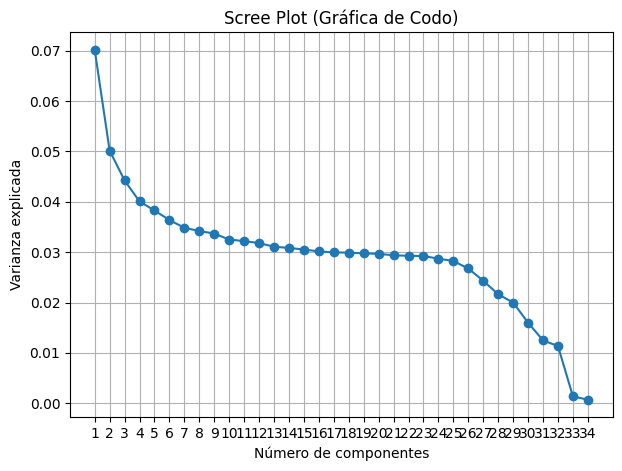

Varianza por componente: [0.07021705 0.05018117 0.04425166 0.04007489 0.0382851  0.03639015
 0.03484393 0.03420503 0.03369654 0.03250259 0.03220622 0.03179929
 0.03108624 0.03084763 0.03053223 0.03015346 0.02995045 0.02991702
 0.02975672 0.02967523 0.02937705 0.02928465 0.02923329 0.02871009
 0.02823961 0.02675876 0.02431716 0.02163447 0.01999459 0.0159901
 0.01247687 0.01135667 0.00136226 0.00069183]
Varianza acumulada: [0.07021705 0.12039822 0.16464988 0.20472478 0.24300987 0.27940003
 0.31424396 0.34844899 0.38214552 0.41464811 0.44685433 0.47865361
 0.50973985 0.54058748 0.57111971 0.60127317 0.63122362 0.66114065
 0.69089737 0.7205726  0.74994965 0.7792343  0.80846759 0.83717768
 0.86541729 0.89217605 0.91649321 0.93812767 0.95812226 0.97411237
 0.98658924 0.99794591 0.99930817 1.        ]


In [19]:
#Gráfica del codo (Scree Plot)
pca_full = PCA()
pca_full.fit(X_scaled_imputed)
plt.figure(figsize=(7,5))
plt.plot(
range(1, len(pca_full.explained_variance_ratio_) + 1),
pca_full.explained_variance_ratio_,
marker='o'
)
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Gráfica de Codo)")
plt.grid(True)
plt.show()
print("Varianza por componente:", pca_full.explained_variance_ratio_)
print("Varianza acumulada:", pca_full.explained_variance_ratio_.cumsum())

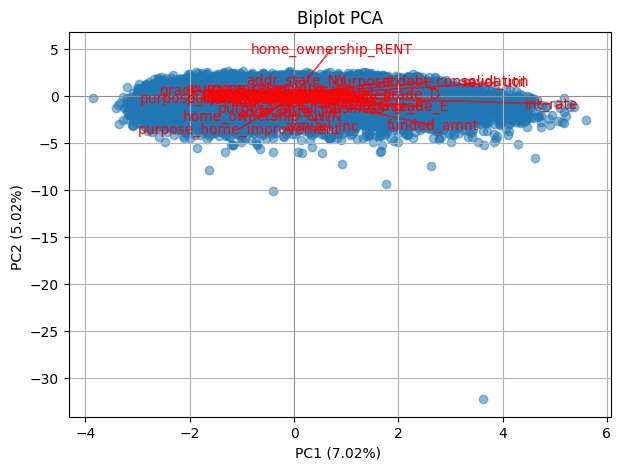

In [22]:
#Gráfico Biplot
pca = PCA(n_components=6)  # Definimos el PCA con 6 componentes
components = pca.fit_transform(X_scaled_imputed)   # Calcular el PCA
# Componentes
PC1 = components[:, 0]
PC2 = components[:, 1]
PC3 = components[:, 2]
PC4 = components[:, 3]
PC5 = components[:, 4]
PC6 = components[:, 5]
loadings = pca.components_.T
# loadings (vectores)
variables = X_encoded.columns   # Guarda los nombres de las variables originales (codificadas)
plt.figure(figsize=(7,5))
# Graficar puntos (scores)
plt.scatter(PC1, PC2, alpha=0.5)
# Etiquetas de ejes
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%) ")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%) ")
# Graficar vectores (loadings)
for i, var in enumerate(variables):
    plt.arrow(0, 0,
              loadings[i,0]*9,   #  multiplicador para mejorar visualización
              loadings[i,1]*9,
              color='red',
              alpha=0.7,
              head_width=0.05)
    plt.text(loadings[i,0]*9.2,
             loadings[i,1]*9.2,
             var, color='red', ha='center', va='center')
plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

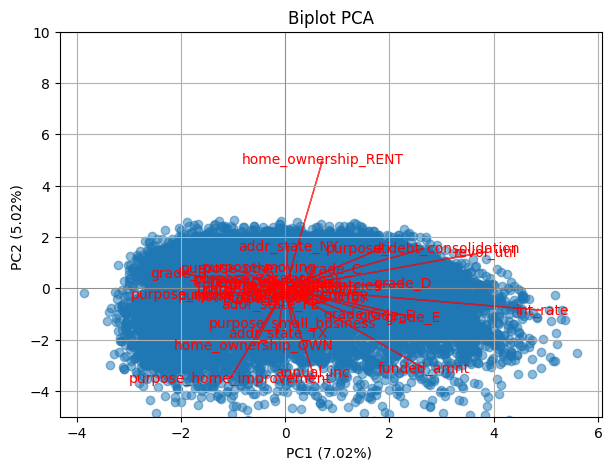

In [24]:
#Mejorar Apariencia limitando el rango de valores en el eje
pca = PCA(n_components=6)  # Definimos el PCA con 6 componentes
components = pca.fit_transform(X_scaled_imputed)   # Calcular el PCA
# Componentes
PC1 = components[:, 0]
PC2 = components[:, 1]
PC3 = components[:, 2]
PC4 = components[:, 3]
PC5 = components[:, 4]
PC6 = components[:, 5]
loadings = pca.components_.T
# loadings (vectores)
variables = X_encoded.columns   # Guarda los nombres de las variables originales (codificadas)
plt.figure(figsize=(7,5))
# Graficar puntos (scores)
plt.scatter(PC1, PC2, alpha=0.5)
# Etiquetas de ejes
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%) ")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%) ")
plt.ylim(-5, 10)  # Ajustar
# Graficar vectores (loadings)
for i, var in enumerate(variables):
    plt.arrow(0, 0,
              loadings[i,0]*9,   #  multiplicador para mejorar visualización
              loadings[i,1]*9,
              color='red',
              alpha=0.7,
              head_width=0.05)
    plt.text(loadings[i,0]*9.2,
             loadings[i,1]*9.2,
             var, color='red', ha='center', va='center')
plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

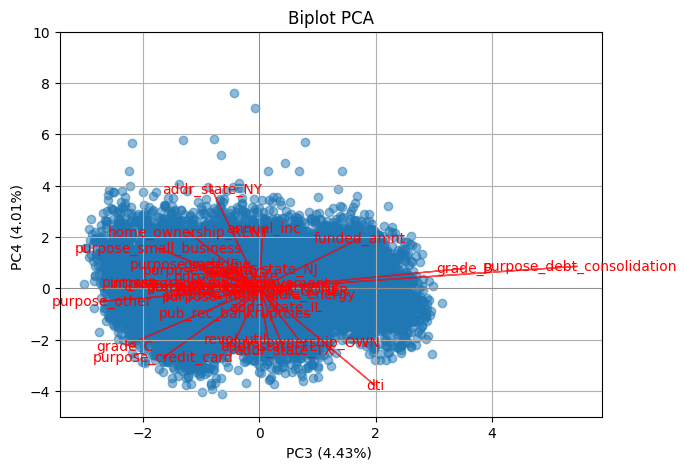

In [26]:
#Biplot de componentes PC3 y PC4
pca = PCA(n_components=6)  # Definimos el PCA con 6 componentes
components = pca.fit_transform(X_scaled_imputed)   # Calcular el PCA
# Componentes
PC1 = components[:, 0]
PC2 = components[:, 1]
PC3 = components[:, 2]
PC4 = components[:, 3]
PC5 = components[:, 4]
PC6 = components[:, 5]
loadings = pca.components_.T
# loadings (vectores)
variables = X_encoded.columns   # Guarda los nombres de las variables originales (codificadas)
plt.figure(figsize=(7,5))
# Graficar puntos (scores)
plt.scatter(PC3, PC4, alpha=0.5 )
# Etiquetas de ejes
plt.xlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%) ")
plt.ylabel(f"PC4 ({pca.explained_variance_ratio_[3]*100:.2f}%) ")
plt.ylim(-5, 10)  # Ajustar
# Graficar vectores (loadings)
for i, var in enumerate(variables):
    plt.arrow(0, 0,
              loadings[i,2]*9,   #  multiplicador para mejorar visualización
              loadings[i,3]*9,
              color='red',
              alpha=0.7,
              head_width=0.05)
    plt.text(loadings[i,2]*9.2,
             loadings[i,3]*9.2,
             var, color='red', ha='center', va='center')
plt.title("Biplot PCA")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()